<a href="https://colab.research.google.com/github/EmmanuelEjima/Data-Science-Machine-Learning-Portfolio/blob/main/Titanic_Survival_EDA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Environment Setup
Importing libraries and configuring visualization settings.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global visualization settings
sns.set_theme(style="whitegrid")
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

# Phase 2: Data Acquisition
Loading the Titanic dataset.

In [3]:
# 2. Load the dataset
from google.colab import files

uploaded = files.upload()


Saving Titanic Dataset (1).csv to Titanic Dataset (1) (1).csv


In [4]:
EDA = pd.read_csv('Titanic Dataset (1).csv')
print(f"Dataset Shape: {EDA.shape}")
EDA.head()
#EDA.info()

Dataset Shape: (1309, 28)


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


# Phase 3: Data Cleaning & Engineering
Handling missing values, renaming columns, and creating new features.

In [24]:
# Step 0: Baseline Data Quality Check
print("Initial Missing Values in Raw Data:")
display(EDA.isnull().sum())

Initial Missing Values in Raw Data:


,0
Passengerid,0
Age,0
Fare,0
Sex,0
sibsp,0
zero,0
zero.1,0
zero.2,0
zero.3,0
zero.4,0


### Summary of Phase 3 Operations:

*   **Dropping 'Zero' Columns:** The original dataset contained multiple redundant columns filled with zeros. Removing these reduces noise and memory usage, ensuring our analysis focuses only on predictive data.
*   **Mapping Variables (`Sex`, `Embarked`):** Converting numeric codes into human-readable labels (e.g., 'Male/Female', 'S/C/Q') is critical for creating intuitive visualizations and understanding group-based trends.
*   **Family Engineering (`FamilySize`, `IsAlone`):** Combining `sibsp` (siblings/spouses) and `Parch` (parents/children) allows us to study survival from a social perspective, testing if traveling as a unit impacted survival odds.
*   **Binning (`AgeGroup`, `FareGroup`):** Continuous variables like Age and Fare can be noisy. Binning them into categories (e.g., 'Child', 'High Fare') helps identify survival patterns across broader life stages and socio-economic classes.

In [12]:
# 1. Consolidated Data Cleaning and Feature Engineering

# Drop placeholder 'zero' columns
columns_to_drop = [col for col in EDA.columns if 'zero' in col]
EDA_cleaned = EDA.drop(columns=columns_to_drop).copy()

# Rename Target variable
EDA_cleaned.rename(columns={'2urvived': 'Survived'}, inplace=True)

# Handle Embarked: Mode imputation and meaningful labels
embarked_mode = EDA_cleaned['Embarked'].mode()[0]
EDA_cleaned['Embarked'] = EDA_cleaned['Embarked'].fillna(embarked_mode).astype(int)
# Standard mapping: 1:S, 2:C, 3:Q, 0:Unknown
EDA_cleaned['Embarked'] = EDA_cleaned['Embarked'].map({1: 'S', 2: 'C', 3: 'Q', 0: 'Unknown'}).astype('category')

# Handle Sex mapping
EDA_cleaned['Sex'] = EDA_cleaned['Sex'].map({0: 'Male', 1: 'Female'}).astype('category')

# 2. Feature Engineering
# Family Dynamics
EDA_cleaned['FamilySize'] = EDA_cleaned['sibsp'] + EDA_cleaned['Parch'] + 1
EDA_cleaned['IsAlone'] = (EDA_cleaned['FamilySize'] == 1).astype(int)

# Age Binning
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']
EDA_cleaned['AgeGroup'] = pd.cut(EDA_cleaned['Age'], bins=age_bins, labels=age_labels, right=False)

# Fare Binning (Quantiles)
EDA_cleaned['FareGroup'] = pd.qcut(EDA_cleaned['Fare'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

print("Cleaning and Feature Engineering Complete.")
EDA_cleaned.info()
display(EDA_cleaned.head())

Cleaning and Feature Engineering Complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Passengerid  1309 non-null   int64   
 1   Age          1309 non-null   float64 
 2   Fare         1309 non-null   float64 
 3   Sex          1309 non-null   category
 4   sibsp        1309 non-null   int64   
 5   Parch        1309 non-null   int64   
 6   Pclass       1309 non-null   int64   
 7   Embarked     1309 non-null   category
 8   Survived     1309 non-null   int64   
 9   FamilySize   1309 non-null   int64   
 10  IsAlone      1309 non-null   int64   
 11  AgeGroup     1309 non-null   category
 12  FareGroup    1309 non-null   category
dtypes: category(4), float64(2), int64(7)
memory usage: 97.9 KB


,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived,FamilySize,IsAlone,AgeGroup,FareGroup
0,1,22.0,7.2500,Male,1,0,3,C,0,2,0,Young Adult,Low
1,2,38.0,71.2833,Female,1,0,1,Unknown,1,2,0,Adult,High
2,3,26.0,7.9250,Female,0,0,3,C,1,1,1,Young Adult,Medium-Low
3,4,35.0,53.1000,Female,1,0,1,C,1,2,0,Adult,High
4,5,35.0,8.0500,Male,0,0,3,C,0,1,1,Adult,Medium-Low


# Phase 4: Exploratory Data Analysis

In this section, we analyze survival probabilities across different demographics and socio-economic features.

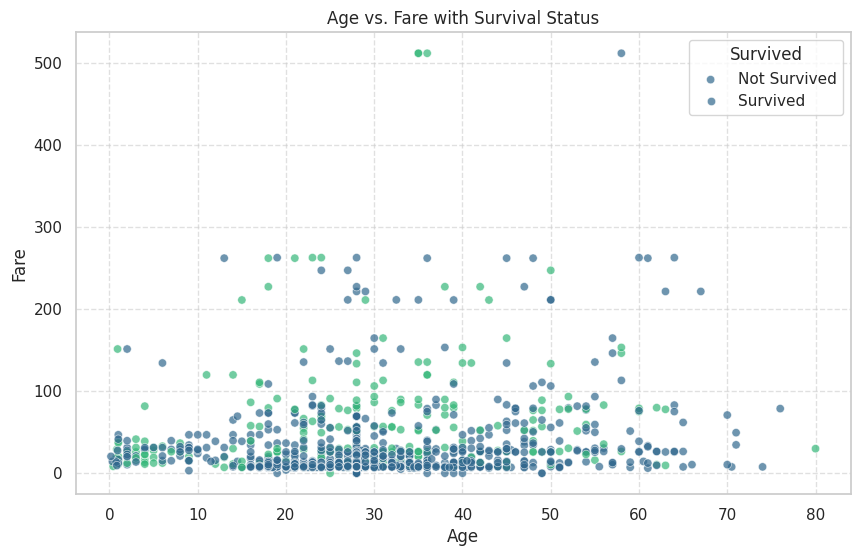

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=EDA_cleaned, x='Age', y='Fare', hue='Survived', palette='viridis', alpha=0.7)
plt.title('Age vs. Fare with Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend(title='Survived', loc='upper right', labels=['Not Survived', 'Survived'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 4.1. Spatial and Density Analysis: Age vs. Fare

/tmp/ipykernel_702/2508404630.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=EDA_cleaned, x='AgeGroup', y='Survived', palette='coolwarm', ax=axes[0])
/tmp/ipykernel_702/2508404630.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=EDA_cleaned, x='FareGroup', y='Survived', palette='plasma', ax=axes[1])
/tmp/ipykernel_702/2508404630.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=EDA_cleaned, x='Embarked', y='Survived', palette='cubehelix', ax=axes[2])


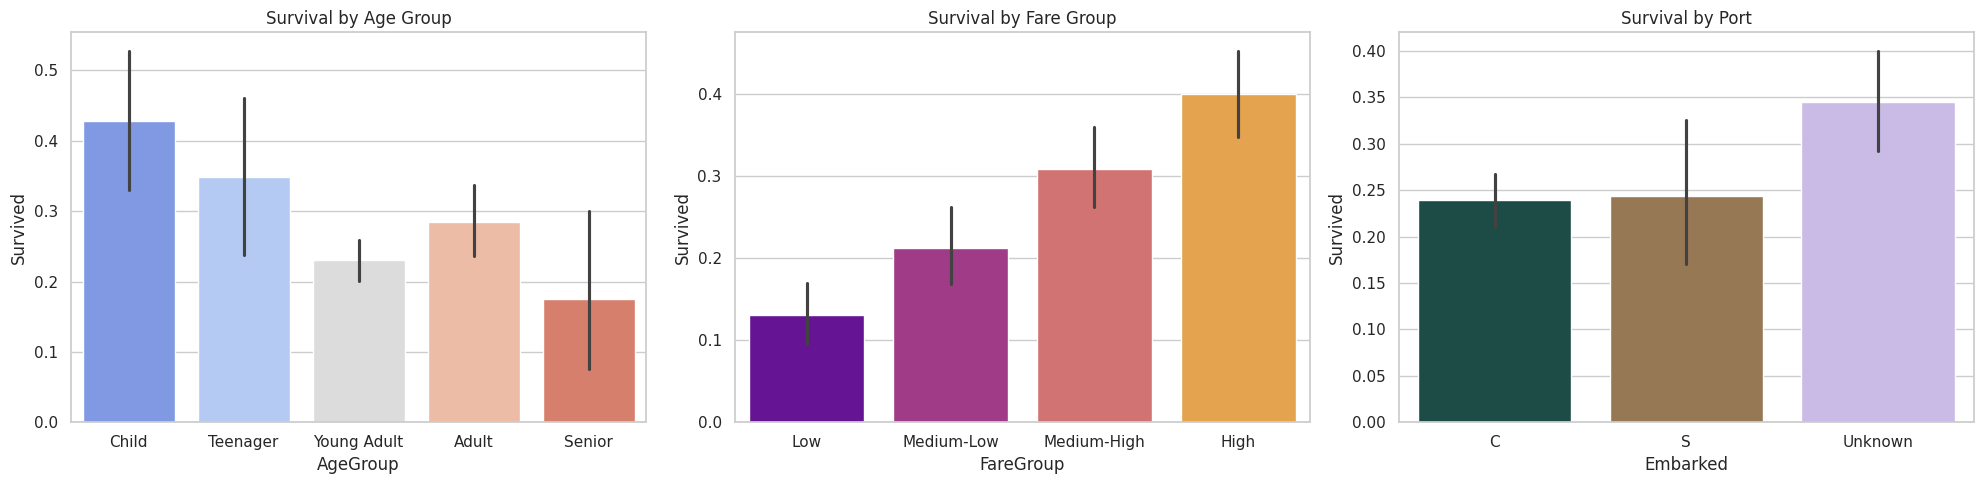

In [13]:
# Analysis: Survival by Age, Fare, and Port
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Age Group
sns.barplot(data=EDA_cleaned, x='AgeGroup', y='Survived', palette='coolwarm', ax=axes[0])
axes[0].set_title('Survival by Age Group')

# 2. Fare Group
sns.barplot(data=EDA_cleaned, x='FareGroup', y='Survived', palette='plasma', ax=axes[1])
axes[1].set_title('Survival by Fare Group')

# 3. Port of Embarkation
sns.barplot(data=EDA_cleaned, x='Embarked', y='Survived', palette='cubehelix', ax=axes[2])
axes[2].set_title('Survival by Port')

plt.tight_layout()
plt.show()

### 4.2. Categorical Survival Rates: Age, Fare, and Port

### 4.3. Demographic Interplay: Class and Sex

<Figure size 1000x600 with 0 Axes>

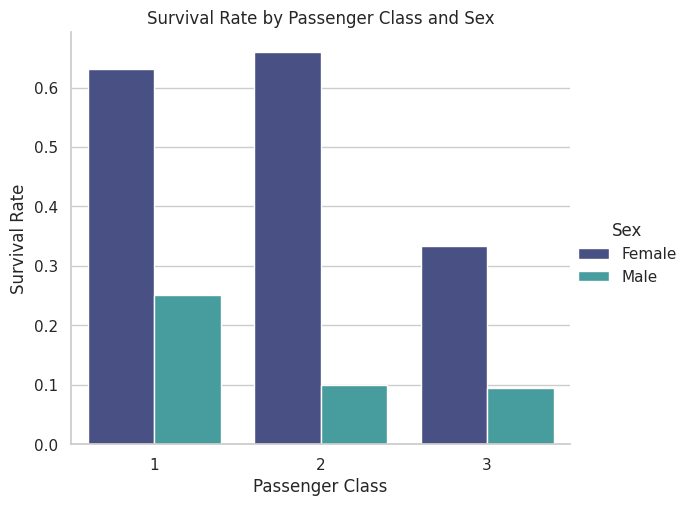

   Pclass     Sex  Survived
0       1  Female  0.631944
1       1    Male  0.251397
2       2  Female  0.660377
3       2    Male  0.099415
4       3  Female  0.333333
5       3    Male  0.095335


/tmp/ipykernel_702/4018025073.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(EDA_cleaned.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index())


In [19]:
plt.figure(figsize=(10, 6))
sns.catplot(data=EDA_cleaned, x='Pclass', y='Survived', hue='Sex', kind='bar', palette='mako', errorbar=None, height=5, aspect=1.2)
plt.title('Survival Rate by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

print(EDA_cleaned.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index())

<!-- Consolidated into Phase 3 -->

<!-- Cell removed -->

### 4.4. Granular Multivariate & Correlation Analysis

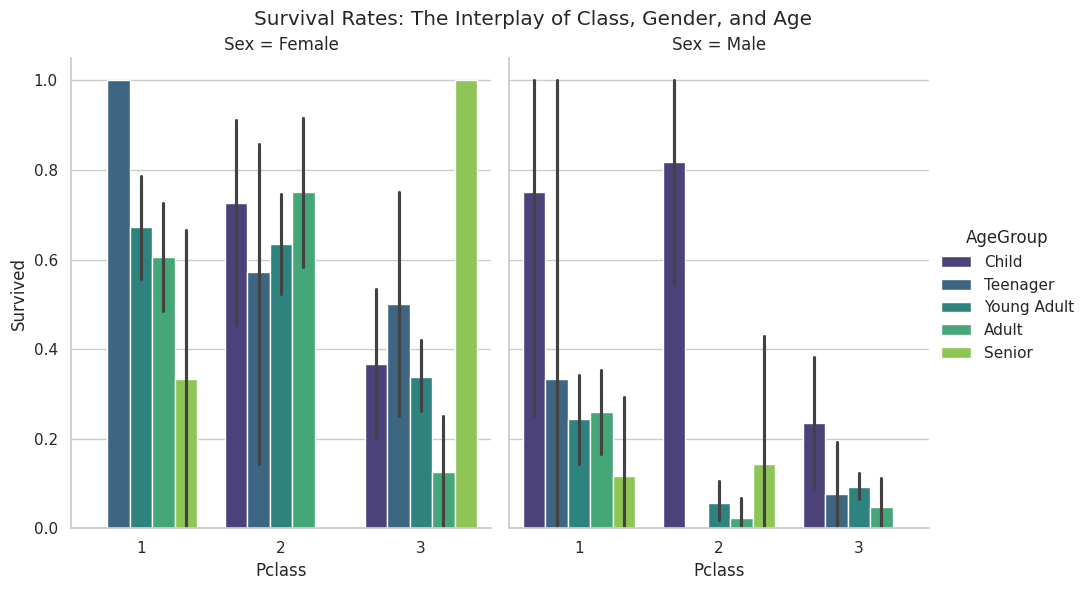

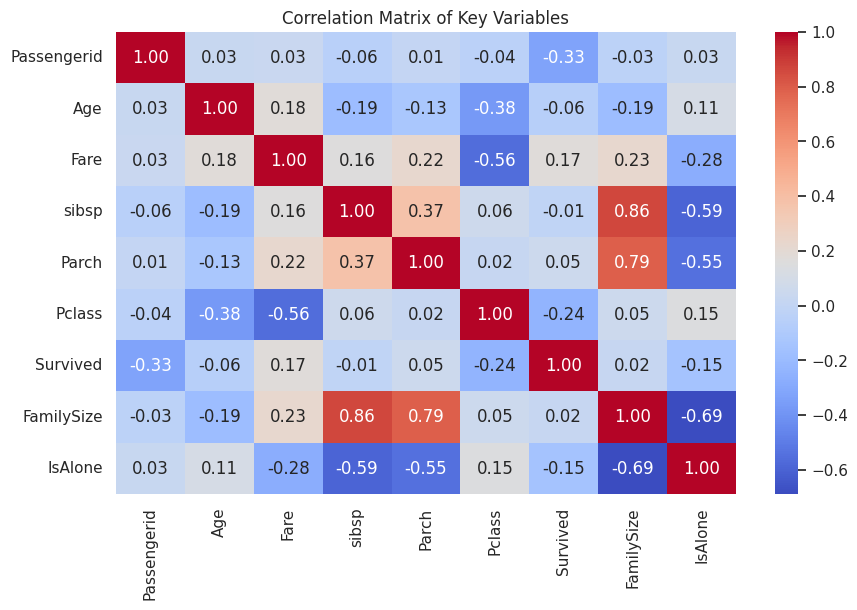

In [20]:
# 1. Multivariate Analysis (Pclass vs Sex vs AgeGroup)
# This addresses the 'granular' and 'conforming' feedback
sns.catplot(data=EDA_cleaned, x='Pclass', y='Survived', hue='AgeGroup', col='Sex', kind='bar', palette='viridis', height=6, aspect=0.8)
plt.subplots_adjust(top=0.9)
plt.suptitle('Survival Rates: The Interplay of Class, Gender, and Age')
plt.show()

# 2. Correlation Analysis (Relationship between numerical variables)
plt.figure(figsize=(10, 6))
sns.heatmap(EDA_cleaned.select_dtypes(include=[np.number]).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Key Variables')
plt.show()

### 4.5. Distribution Deep Dive: Age and Fare KDE

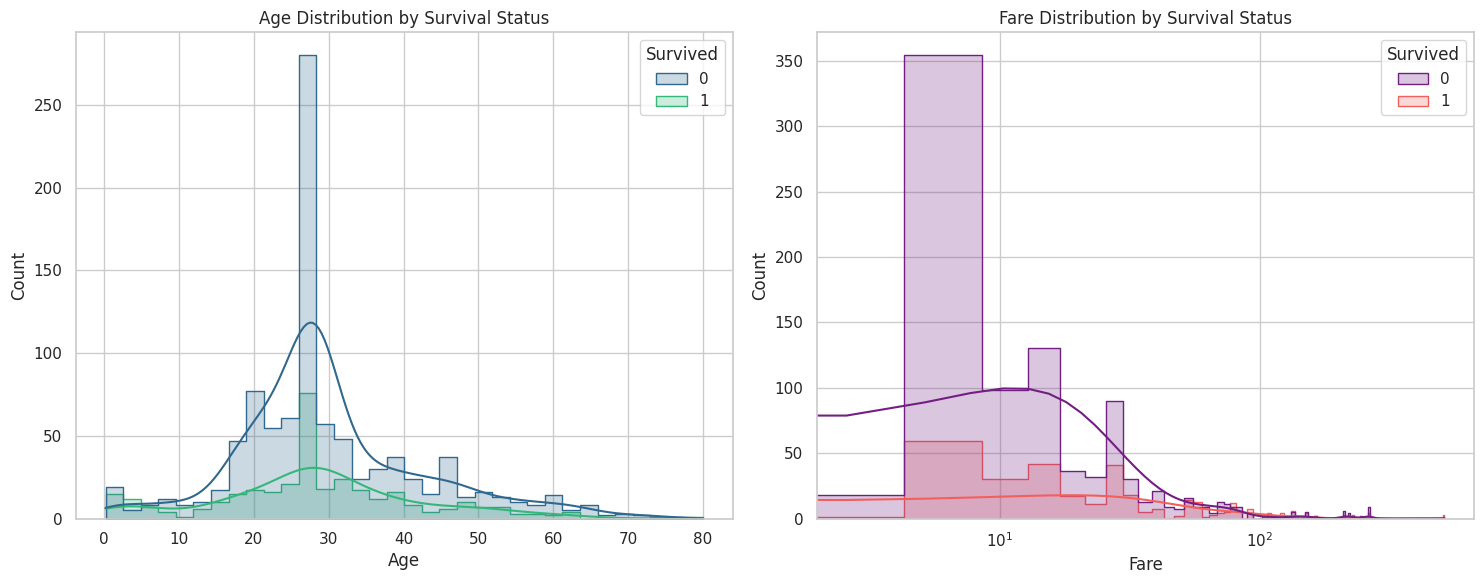

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Distribution of Age by Survival
sns.histplot(data=EDA_cleaned, x='Age', hue='Survived', kde=True, element='step', palette='viridis', ax=axes[0])
axes[0].set_title('Age Distribution by Survival Status')

# Distribution of Fare by Survival (Log scale to handle skewness)
sns.histplot(data=EDA_cleaned, x='Fare', hue='Survived', kde=True, element='step', palette='magma', ax=axes[1])
axes[1].set_title('Fare Distribution by Survival Status')
axes[1].set_xscale('log') # Better visibility for skewed fare data

plt.tight_layout()
plt.show()

### 4.6. Family Dynamics: Family Size vs. Survival

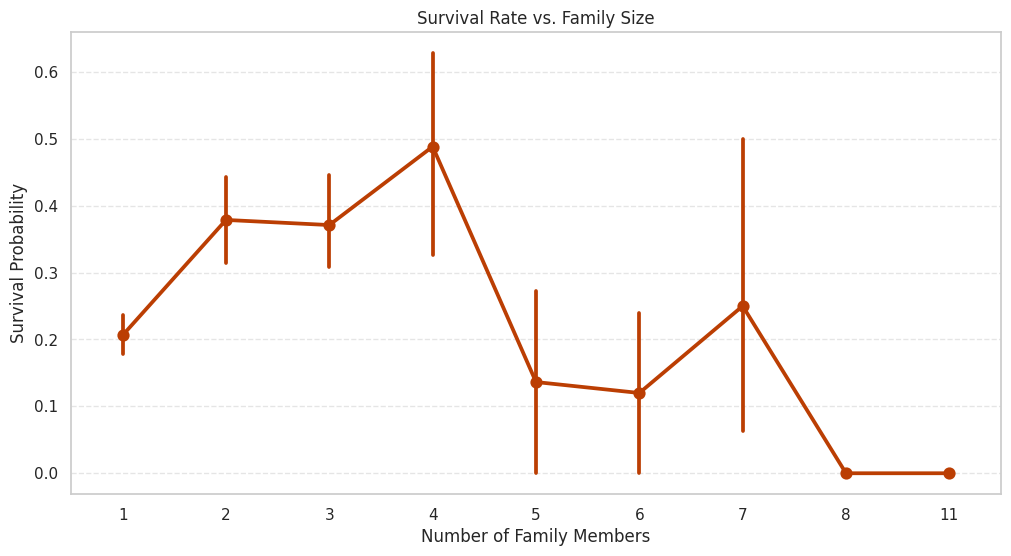

Average survival rate for alone passengers: 0.20632911392405062
Average survival rate for passengers with family: 0.3448940269749518


In [22]:
plt.figure(figsize=(12, 6))

# Survival rate by Family Size
sns.pointplot(data=EDA_cleaned, x='FamilySize', y='Survived', color='#bb3e03')
plt.title('Survival Rate vs. Family Size')
plt.xlabel('Number of Family Members')
plt.ylabel('Survival Probability')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

print("Average survival rate for alone passengers:", EDA_cleaned[EDA_cleaned['IsAlone'] == 1]['Survived'].mean())
print("Average survival rate for passengers with family:", EDA_cleaned[EDA_cleaned['IsAlone'] == 0]['Survived'].mean())

<!-- Cell removed -->

# Phase 5: Final Summary & Insights

### The Titanic Survival Story:
- **Demographics**: Women and children (especially in 1st Class) had significantly higher survival rates.
- **Economic Status**: A clear relationship exists between `Pclass`/`Fare` and survival.
- **Family Dynamics**: Small families (2-4 members) had the highest survival probability (~34%).
- **Multivariate Interplay**: High-class females and children were prioritized, while adult males in 3rd class faced the lowest odds.

**Conclusion**: Survival was a complex function of socio-economic status, gender roles, and family support structures.